# Clase 6 (R) — Actor-Crítico, PPO y aplicaciones contemporáneas

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Cuaderno:** `Clase06_ActorCritico_PPO_R.ipynb`

---

## Resumen del cuaderno

Este cuaderno reproduce, **desde R**, el estudio comparativo del cuaderno de Python sobre el entorno **LunarLander**. La arquitectura merece una explicación, pues encierra una decisión de diseño deliberada.

> **El aprendizaje por refuerzo profundo es, en su núcleo, PyTorch.** Reimplementarlo en `torch` nativo de R, o manipular objetos de PyTorch dentro de bucles de R, provoca desbordamientos de la pila C de **reticulate**. Por ello adoptamos una división de responsabilidades nítida: el **núcleo numérico** —las redes, el entrenamiento, la evaluación— reside en Python y se invoca mediante `reticulate::source_python`; **R orquesta y visualiza**. R decide qué experimentos correr, recoge los resultados como datos planos y los grafica con **ggplot2**. En ningún momento R itera sobre modelos de PyTorch.

Esta separación, lejos de ser una limitación, es la práctica recomendada: aprovecha la madurez del ecosistema de aprendizaje profundo de Python sin renunciar a la elegancia de R para el análisis y la visualización.

### Convención de semillas

Se emplean **dos** semillas, conforme al estándar del curso:
- `SEMILLA_GLOBAL = 42L` — para todos los experimentos estadísticos (promedios, réplicas, curvas).
- `SEMILLA_VIS = 21L` — exclusivamente para las visualizaciones de un único episodio (las grabaciones).

La separación es metodológica: el azar de una grabación ilustrativa no debe contaminar el azar de los experimentos cuantitativos.

## Preparación del entorno R

El entorno de ejecución **R** de Colab no incluye de fábrica todos los paquetes que el cuaderno necesita —en particular `reticulate`—. La celda siguiente instala los que falten. **Ejecútela primero**; la instalación de `reticulate` puede tardar uno o dos minutos la primera vez, y sólo es necesaria una vez por sesión.

In [1]:
# === Preparación del entorno R (ejecutar PRIMERO) ===
paquetes <- c("reticulate", "ggplot2", "dplyr", "tidyr")
faltan <- paquetes[!vapply(paquetes, requireNamespace, logical(1), quietly = TRUE)]
if (length(faltan)) {
  message("Instalando paquetes de R: ", paste(faltan, collapse = ", "), " ...")
  install.packages(faltan)
}
cat("Paquetes de R listos:", paste(paquetes, collapse = ", "), "\n")

Instalando paquetes de R: reticulate ...

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’




Paquetes de R listos: reticulate, ggplot2, dplyr, tidyr 


## Puente con Python (reticulate)

La celda siguiente tiende el puente con Python. En el entorno **R** de Colab, el flujo automático basado en `py_require()`/`uv` puede fallar por conflictos al resolver dependencias; por ello adoptamos una vía más robusta: instalamos las dependencias con `pip` en el **Python del sistema** de Colab y fijamos reticulate a ese intérprete con `use_python(..., required = TRUE)`. A continuación, la celda escribe el núcleo numérico en disco y lo carga con `source_python`.

> **Si ya intentó una versión con `py_require()` y falló:** reinicie el entorno de ejecución (*Entorno de ejecución → Reiniciar sesión*) antes de ejecutar esta celda, para limpiar el estado de reticulate.

In [2]:
# === Puente con Python (Colab R) — versión robusta ===
# IMPORTANTE: si hubo intentos previos fallidos, REINICIE el entorno
# (Entorno de ejecución > Reiniciar sesión) ANTES de ejecutar esta celda.

suppressMessages({ library(reticulate); library(ggplot2); library(dplyr); library(tidyr) })

# 1) Fijar reticulate al Python del sistema de Colab
PYBIN <- Sys.which("python3"); if (PYBIN == "") PYBIN <- "/usr/bin/python3"
use_python(PYBIN, required = TRUE)
real_py <- py_exe()                     # el ejecutable que reticulate USA realmente
cat("Python de reticulate:", real_py, "\n")

# 2) Instalar dependencias EN ese intérprete, por pasos (aislando box2d)
pip <- function(pkgs) system(paste(shQuote(real_py), "-m pip install -q", pkgs))
pip("swig")
pip("stable-baselines3 gymnasium imageio")   # primero lo seguro
pip("'gymnasium[box2d]'")                     # box2d aparte: si falla, no arrastra al resto

# 3) Verificar ANTES de cargar el núcleo
cat("stable_baselines3:", py_module_available("stable_baselines3"),
    "| gymnasium:", py_module_available("gymnasium"), "\n")

# 4) Núcleo numérico (Python) embebido y cargado
codigo_nucleo <- r"---(


# -*- coding: utf-8 -*-
"""Núcleo numérico para el cuaderno R de la Clase 6.
Expone funciones de ALTO NIVEL que devuelven datos planos (listas/escalares),
de modo que R orqueste y visualice sin manipular objetos PyTorch en bucles."""
import warnings; warnings.filterwarnings("ignore")
import os
import matplotlib; matplotlib.use("Agg")
import numpy as np, torch as th, torch.nn as nn, torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from stable_baselines3 import DQN, A2C, PPO
from stable_baselines3.dqn.policies import DQNPolicy, QNetwork
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.utils import polyak_update

ENV_ID = "LunarLander-v3"
DISPOSITIVO = "cuda" if th.cuda.is_available() else "cpu"
NAVY, ORANGE, TEAL, GRAY, RED, GREEN = "#1E3A5F","#D86A2C","#2E8A99","#4A4A4A","#B23A48","#2E7D5B"

# ---------------- Double DQN ----------------
class DoubleDQN(DQN):
    def train(self, gradient_steps, batch_size=100):
        self.policy.set_training_mode(True); self._update_learning_rate(self.policy.optimizer)
        for _ in range(gradient_steps):
            rd = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            with th.no_grad():
                na = self.q_net(rd.next_observations).argmax(dim=1, keepdim=True)
                nq = self.q_net_target(rd.next_observations).gather(1, na)
                tq = rd.rewards + (1 - rd.dones) * self.gamma * nq
            cq = self.q_net(rd.observations).gather(1, rd.actions.long())
            loss = F.smooth_l1_loss(cq, tq)
            self.policy.optimizer.zero_grad(); loss.backward()
            th.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()
        self._n_updates += gradient_steps
        if self._n_updates % self.target_update_interval == 0:
            polyak_update(self.q_net.parameters(), self.q_net_target.parameters(), self.tau)

# ---------------- Dueling ----------------
class RedDueling(QNetwork):
    def __init__(self, *a, **k):
        super().__init__(*a, **k); n=int(self.action_space.n); d=self.features_dim
        self.corriente_valor   = nn.Sequential(nn.Linear(d,128), nn.ReLU(), nn.Linear(128,1))
        self.corriente_ventaja = nn.Sequential(nn.Linear(d,128), nn.ReLU(), nn.Linear(128,n))
        self.q_net = nn.Identity()
    def forward(self, obs):
        ft = self.extract_features(obs, self.features_extractor)
        v = self.corriente_valor(ft); a = self.corriente_ventaja(ft)
        return v + (a - a.mean(dim=1, keepdim=True))
class PoliticaDueling(DQNPolicy):
    def make_q_net(self):
        args = self._update_features_extractor(self.net_args, features_extractor=None)
        return RedDueling(**args).to(self.device)

# ---------------- Evaluación periódica ----------------
class RegistradorEval(BaseCallback):
    def __init__(self, env_eval, eval_freq, n_eval=3):
        super().__init__(); self.env_eval=env_eval; self.eval_freq=eval_freq; self.n_eval=n_eval
        self.pasos=[]; self.media=[]; self.desv=[]
    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            r,_ = evaluate_policy(self.model, self.env_eval, n_eval_episodes=self.n_eval,
                                  deterministic=True, return_episode_rewards=True)
            self.pasos.append(self.num_timesteps); self.media.append(float(np.mean(r)))
            self.desv.append(float(np.std(r, ddof=1)) if len(r)>1 else 0.0)
        return True

_FAB = {"DQN":DQN, "DoubleDQN":DoubleDQN, "A2C":A2C, "PPO":PPO, "Dueling":DQN}
cfg_DQN = dict(policy_kwargs=dict(net_arch=[256,256]), learning_rate=6.3e-4, buffer_size=50000,
    learning_starts=1000, batch_size=128, gamma=0.99, train_freq=4, gradient_steps=1,
    target_update_interval=250, exploration_fraction=0.16, exploration_final_eps=0.05)
cfg_A2C = dict(policy_kwargs=dict(net_arch=[128,128]), gamma=0.999, gae_lambda=0.95, ent_coef=0.01, n_steps=8)
cfg_PPO = dict(policy_kwargs=dict(net_arch=[128,128]), n_steps=1024, batch_size=64, gamma=0.999,
    gae_lambda=0.98, clip_range=0.2, ent_coef=0.01, n_epochs=4)

def _entrenar(algoritmo, pasos, semilla, eval_freq, n_eval=3, **kw):
    env=Monitor(gym.make(ENV_ID)); ev=Monitor(gym.make(ENV_ID))
    pol = PoliticaDueling if algoritmo=="Dueling" else "MlpPolicy"
    m = _FAB[algoritmo](pol, env, seed=int(semilla), verbose=0, device=DISPOSITIVO, **kw)
    reg = RegistradorEval(ev, eval_freq, n_eval); m.learn(total_timesteps=int(pasos), callback=reg)
    env.close(); ev.close()
    return m, np.array(reg.pasos), np.array(reg.media), np.array(reg.desv)

# ============== FUNCIONES DE ALTO NIVEL (devuelven datos planos) ==============
def info_entorno():
    env = gym.make(ENV_ID)
    d = dict(dim_estado=int(env.observation_space.shape[0]),
             n_acciones=int(env.action_space.n), umbral=200.0,
             gym=gym.__version__)
    env.close(); return d

def desempeno_aleatorio(n_episodios=12, semilla=42):
    env=gym.make(ENV_ID); R=[]
    for k in range(int(n_episodios)):
        obs,_=env.reset(seed=int(semilla)+k); term=trunc=False; tot=0.0
        while not (term or trunc):
            obs,r,term,trunc,_=env.step(env.action_space.sample()); tot+=r
        R.append(float(tot))
    env.close(); return R

def _montaje(frames, titulo, ruta_png, color):
    idx=np.linspace(0,len(frames)-1,5).astype(int)
    fig,axes=plt.subplots(1,5,figsize=(12,2.4))
    for ax,i in zip(axes,idx):
        ax.imshow(frames[i]); ax.axis("off"); ax.set_title(f"t = {i}", fontsize=9, color=color)
    fig.suptitle(titulo, color=NAVY, fontsize=12, y=1.03)
    plt.tight_layout(); fig.savefig(ruta_png, dpi=90, bbox_inches="tight"); plt.close(fig)

def _grabar(modelo, ruta_gif, ruta_png, semilla, titulo, color, max_pasos=400):
    env=gym.make(ENV_ID, render_mode="rgb_array")
    obs,_=env.reset(seed=int(semilla)); frames=[]; tot=0.0; term=trunc=False; n=0
    while not (term or trunc) and n<max_pasos:
        a = env.action_space.sample() if modelo is None else modelo.predict(obs, deterministic=True)[0]
        obs,r,term,trunc,_=env.step(a); tot+=r; frames.append(env.render()); n+=1
    env.close()
    imageio.mimsave(ruta_gif, frames[::2], duration=50)
    _montaje(frames, titulo, ruta_png, color)
    return float(tot)

def grabar_aleatorio(ruta_gif, ruta_png, semilla):
    ret=_grabar(None, ruta_gif, ruta_png, semilla, "Politica aleatoria: descenso descontrolado", RED)
    return dict(retorno=ret, gif=ruta_gif, png=ruta_png)

def comparar_familias(main_steps, eval_freq, semilla):
    res={}
    for nombre,cfg in [("DQN",cfg_DQN),("A2C",cfg_A2C),("PPO",cfg_PPO)]:
        _,ps,me,sd=_entrenar(nombre, main_steps, semilla, eval_freq, **cfg)
        res[nombre]=dict(pasos=ps.tolist(), media=me.tolist(), desv=sd.tolist())
    return res

def comparar_valor(value_steps, eval_freq, semilla):
    res={}
    for nombre in ["DQN","DoubleDQN","Dueling"]:
        _,ps,me,sd=_entrenar(nombre, value_steps, semilla, eval_freq, **cfg_DQN)
        res[nombre]=dict(pasos=ps.tolist(), media=me.tolist(), desv=sd.tolist())
    return res

def barrido(param, valores, sweep_steps, replicas, semilla_base):
    res={}
    for v in valores:
        finales=[]
        for rep in range(int(replicas)):
            cfg=dict(cfg_PPO); cfg[param]=v
            _,_,me,_=_entrenar("PPO", sweep_steps, int(semilla_base)+rep, eval_freq=int(sweep_steps), n_eval=3, **cfg)
            finales.append(float(me[-1]))
        res[str(v)]=dict(valor=float(v), media=float(np.mean(finales)),
                         desv=float(np.std(finales,ddof=1)), finales=finales)
    return res

def experto_completo(hero_steps, eval_freq, semilla, gif_seed, ruta_gif, ruta_png, n_rig=30):
    modelo,ps,me,sd=_entrenar("DQN", hero_steps, semilla, eval_freq, **cfg_DQN)
    envm=Monitor(gym.make(ENV_ID))
    ret,_=evaluate_policy(modelo, envm, n_eval_episodes=int(n_rig), deterministic=True, return_episode_rewards=True)
    envm.close(); ret=np.array(ret)
    ret_gif=_grabar(modelo, ruta_gif, ruta_png, gif_seed, "Agente experto: descenso controlado", GREEN)
    return dict(pasos=ps.tolist(), media=me.tolist(), desv=sd.tolist(),
                eval_media=float(ret.mean()), eval_desv=float(ret.std(ddof=1)),
                eval_min=float(ret.min()), eval_max=float(ret.max()),
                resueltos=int((ret>=200).sum()), n_rig=int(n_rig),
                eval_retornos=ret.tolist(), gif=ruta_gif, png=ruta_png, gif_retorno=ret_gif)



)---"
writeLines(codigo_nucleo, "nucleo_rl_clase06.py")
source_python("nucleo_rl_clase06.py")

cat("Puente establecido. Python:", py_config()$python, "\n")
print(info_entorno())

Python de reticulate: /usr/bin/python3 
stable_baselines3: TRUE | gymnasium: TRUE 
Puente establecido. Python: /usr/bin/python3 
$dim_estado
[1] 8

$n_acciones
[1] 4

$umbral
[1] 200

$gym
[1] "1.2.3"



## Bloque 0 — Configuración

Fijamos las dos semillas, la identidad visual institucional, un tema de ggplot2 reutilizable y los presupuestos de cómputo. **Nota:** el cuaderno R emplea presupuestos *reducidos* respecto del estudio de Python; su propósito es reproducir la metodología y las tendencias, no repetir el estudio en toda su extensión. El interruptor `MODO_RAPIDO` permite escalar.

In [3]:
# ---- Semillas (estándar del curso) ----
SEMILLA_GLOBAL <- 42L   # experimentos estadísticos
SEMILLA_VIS    <- 21L   # visualizaciones de un episodio
set.seed(SEMILLA_GLOBAL)

# ---- Paleta institucional Austral ----
NAVY <- "#1E3A5F"; ORANGE <- "#D86A2C"; TEAL <- "#2E8A99"
GRAY <- "#4A4A4A"; RED <- "#B23A48"; GREEN <- "#2E7D5B"

# ---- Tema de ggplot2 ----
tema_austral <- theme_minimal(base_size = 12) +
  theme(plot.title  = element_text(color = NAVY, face = "bold"),
        plot.subtitle = element_text(color = GRAY),
        axis.title  = element_text(color = GRAY),
        panel.grid.minor = element_blank(),
        legend.position = "bottom")
theme_set(tema_austral)

# ---- Utilidades de visualización (IRdisplay) ----
mostrar_png <- function(ruta) if (requireNamespace("IRdisplay", quietly=TRUE)) IRdisplay::display_png(file=ruta)
mostrar_gif <- function(ruta) if (requireNamespace("IRdisplay", quietly=TRUE))
  IRdisplay::display_html(sprintf('<img src="%s" width="460">', ruta))

# ---- Presupuestos de cómputo (reducidos respecto de Python) ----
MODO_RAPIDO <- TRUE
if (MODO_RAPIDO) {
  MAIN_STEPS <- 120000L; VALUE_STEPS <- 80000L
  SWEEP_STEPS <- 80000L; SWEEP_REPLICAS <- 2L
  HERO_STEPS  <- 150000L; EVAL_FREQ <- 4000L
} else {
  MAIN_STEPS <- 400000L; VALUE_STEPS <- 250000L
  SWEEP_STEPS <- 200000L; SWEEP_REPLICAS <- 5L
  HERO_STEPS  <- 500000L; EVAL_FREQ <- 10000L
}
cat(sprintf("MODO_RAPIDO=%s | MAIN=%d | VALUE=%d | SWEEP=%dx%d | HERO=%d\n",
            MODO_RAPIDO, MAIN_STEPS, VALUE_STEPS, SWEEP_STEPS, SWEEP_REPLICAS, HERO_STEPS))

MODO_RAPIDO=TRUE | MAIN=120000 | VALUE=80000 | SWEEP=80000x2 | HERO=150000


## Bloque 1 — El entorno LunarLander

Antes de orquestar los experimentos, conviene asomarse al entorno directamente desde R, lo que ofrece la ocasión de ilustrar los **patrones defensivos de conversión** que el curso ha institucionalizado. Cuando R accede a objetos de Python a través de reticulate, los tipos no siempre se traducen como uno esperaría: una tupla de Python llega como lista de R, un entero de NumPy puede requerir coerción explícita. Importamos, pues, `gymnasium` con `convert = FALSE` y convertimos cada valor en su frontera.

In [4]:
# Importación con convert=FALSE: controlamos la conversión en cada frontera R-Python
gym <- import("gymnasium", convert = FALSE)
env <- gym$make("LunarLander-v3")

# Patrón 1 — una tupla de Python (la forma del espacio) llega como lista: unlist()
dim_estado <- unlist(py_to_r(env$observation_space$shape))
# Patrón 2 — la versión de Python se obtiene con as.character(py_version())
ver_py <- as.character(py_version())
env$close()

# Patrón 3 — los escalares de NumPy (p. ej. action_space$n es np.int64) se coercen
# de forma más robusta del lado de Python; el núcleo ya devuelve enteros nativos.
info <- info_entorno()

cat("Dimensión del estado :", dim_estado, "\n")
cat("Número de acciones   :", info$n_acciones, "\n")
cat("Umbral de resolución :", info$umbral, "\n")
cat("Python               :", ver_py, "\n")

None

Dimensión del estado : 8 
Número de acciones   : 4 
Umbral de resolución : 200 
Python               : 3.12 


### 1.1. La política aleatoria y su grabación

Medimos el desempeño de una política aleatoria —la referencia mínima— y grabamos un episodio. El núcleo Python realiza el *rollout*, guarda el GIF y un montaje de fotogramas; R recibe el retorno y muestra las imágenes.

Política aleatoria: retorno medio = -172.5 ± 117.5 (desv. insesgada, n=12)
Episodio aleatorio: retorno = -137.5


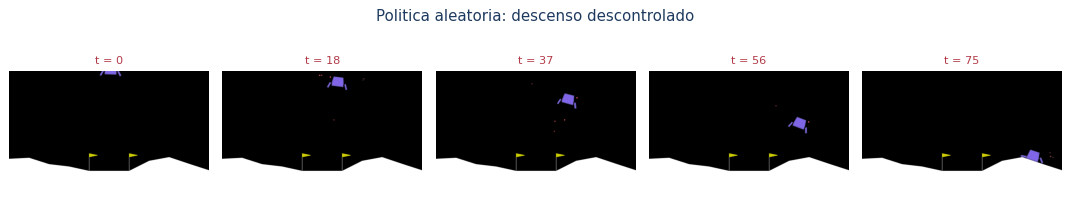

In [5]:
# Desempeño aleatorio (núcleo Python -> vector de R)
ret_aleatorio <- as.numeric(unlist(desempeno_aleatorio(n_episodios = 12L, semilla = SEMILLA_GLOBAL)))
cat(sprintf("Política aleatoria: retorno medio = %.1f ± %.1f (desv. insesgada, n=%d)\n",
            mean(ret_aleatorio), sd(ret_aleatorio), length(ret_aleatorio)))

# Grabación "antes" (usa SEMILLA_VIS: visualización de un episodio)
g_antes <- grabar_aleatorio("lunarlander_antes.gif", "montaje_antes.png", SEMILLA_VIS)
cat(sprintf("Episodio aleatorio: retorno = %.1f\n", g_antes$retorno))
mostrar_png("montaje_antes.png")
mostrar_gif("lunarlander_antes.gif")

## Bloque 2 — Las dos familias sobre LunarLander

Orquestamos el experimento central: DQN (rama de valor) frente a A2C y PPO (rama de política). R invoca una sola función del núcleo, recibe las tres curvas como datos planos, las ensambla en un `data.frame` largo y las grafica con ggplot2. Recuérdese la cautela: importa la **forma** de cada curva, no un veredicto; y PPO, en particular, exhibe un arranque lento cuya culminación varía entre semillas.

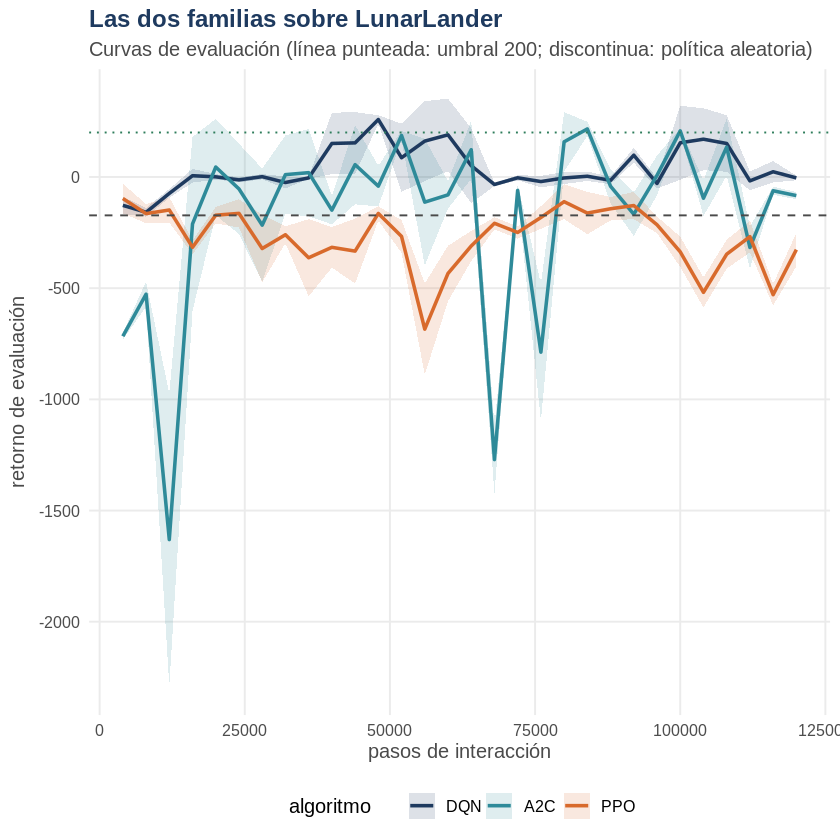

In [6]:
# Función auxiliar: convierte el resultado del núcleo en un data.frame largo
df_curvas <- function(res) {
  do.call(rbind, lapply(names(res), function(a)
    data.frame(algoritmo = a,
               pasos = as.numeric(unlist(res[[a]]$pasos)),
               media = as.numeric(unlist(res[[a]]$media)),
               desv  = as.numeric(unlist(res[[a]]$desv)))))
}

res_familias <- comparar_familias(MAIN_STEPS, EVAL_FREQ, SEMILLA_GLOBAL)
df_fam <- df_curvas(res_familias)
df_fam$algoritmo <- factor(df_fam$algoritmo, levels = c("DQN","A2C","PPO"))

ggplot(df_fam, aes(pasos, media, color = algoritmo, fill = algoritmo)) +
  geom_ribbon(aes(ymin = media - desv, ymax = media + desv), alpha = 0.15, color = NA) +
  geom_line(linewidth = 1) +
  geom_hline(yintercept = 200, linetype = "dotted", color = GREEN) +
  geom_hline(yintercept = mean(ret_aleatorio), linetype = "dashed", color = GRAY) +
  scale_color_manual(values = c(DQN = NAVY, A2C = TEAL, PPO = ORANGE)) +
  scale_fill_manual(values  = c(DQN = NAVY, A2C = TEAL, PPO = ORANGE)) +
  labs(title = "Las dos familias sobre LunarLander",
       subtitle = "Curvas de evaluación (línea punteada: umbral 200; discontinua: política aleatoria)",
       x = "pasos de interacción", y = "retorno de evaluación")

## Bloque 3 — La rama de valor mejorada: Double DQN y Dueling

Entrenamos, con idéntica configuración y semilla, las tres variantes de la rama de valor —DQN estándar, Double DQN y Dueling—. Una sola llamada al núcleo las produce; R las grafica. **Cautela metodológica:** con una única semilla, las ventajas teóricas de Double DQN (menor sesgo) y Dueling rara vez se manifiestan con nitidez; sus curvas se entrelazan, y el ruido entre corridas domina. Es la lección de potencia estadística que el curso subraya.

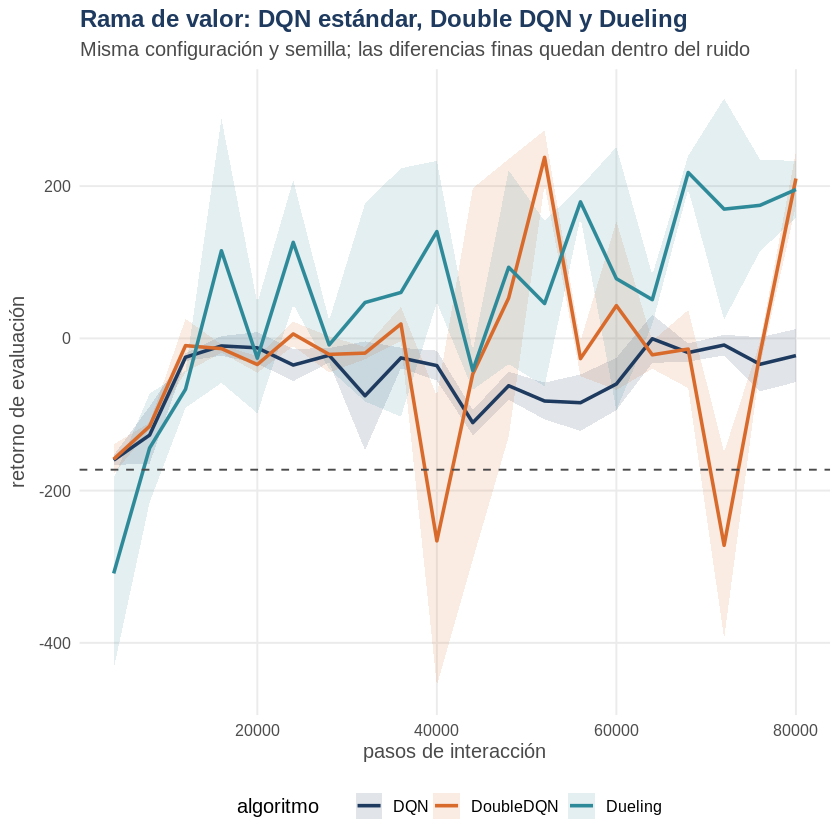

In [7]:
res_valor <- comparar_valor(VALUE_STEPS, EVAL_FREQ, SEMILLA_GLOBAL)
df_val <- df_curvas(res_valor)
df_val$algoritmo <- factor(df_val$algoritmo, levels = c("DQN","DoubleDQN","Dueling"))

ggplot(df_val, aes(pasos, media, color = algoritmo, fill = algoritmo)) +
  geom_ribbon(aes(ymin = media - desv, ymax = media + desv), alpha = 0.13, color = NA) +
  geom_line(linewidth = 1) +
  geom_hline(yintercept = mean(ret_aleatorio), linetype = "dashed", color = GRAY) +
  scale_color_manual(values = c(DQN = NAVY, DoubleDQN = ORANGE, Dueling = TEAL)) +
  scale_fill_manual(values  = c(DQN = NAVY, DoubleDQN = ORANGE, Dueling = TEAL)) +
  labs(title = "Rama de valor: DQN estándar, Double DQN y Dueling",
       subtitle = "Misma configuración y semilla; las diferencias finas quedan dentro del ruido",
       x = "pasos de interacción", y = "retorno de evaluación")

## Bloque 4 — Estudio dirigido (I): el recorte $\epsilon$ de PPO

Barremos el parámetro `clip_range` de PPO con varias réplicas por valor. El núcleo ejecuta todo el bucle anidado en Python —valores por réplicas— y devuelve, para cada valor, la media, la desviación insesgada y los retornos finales individuales. R sólo grafica. **Lectura:** obsérvense las bandas de error y la nube de puntos; con pocas réplicas y un PPO en arranque, los intervalos se solapan y las diferencias no resultan estadísticamente distinguibles.

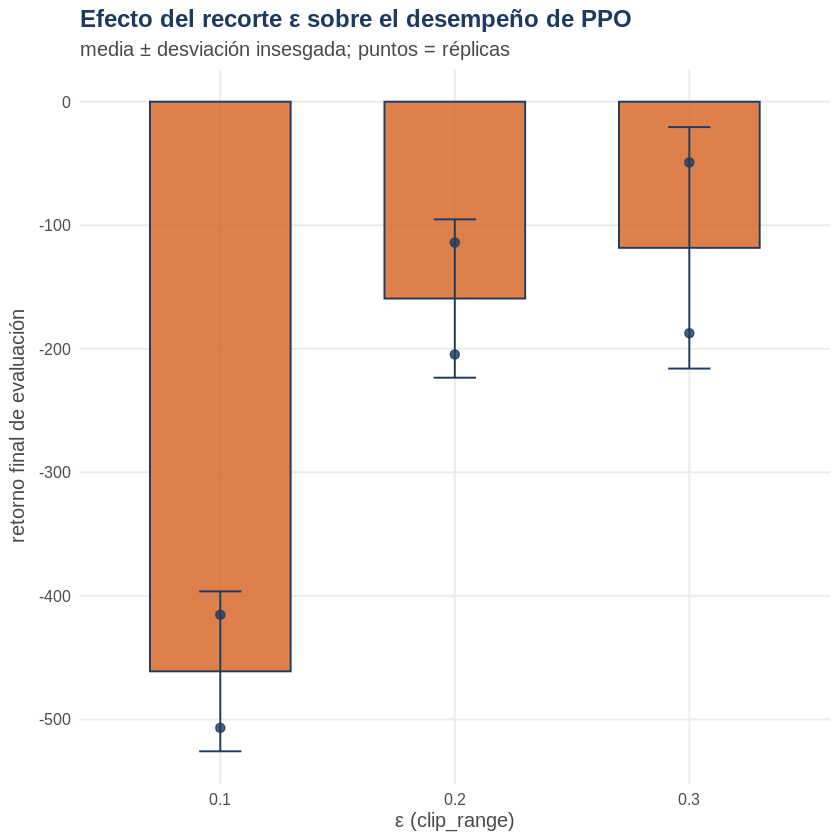

In [8]:
# Funciones auxiliares para los barridos
df_barrido <- function(res) do.call(rbind, lapply(names(res), function(k)
  data.frame(valor = res[[k]]$valor, media = res[[k]]$media, desv = res[[k]]$desv)))
df_puntos  <- function(res) do.call(rbind, lapply(names(res), function(k)
  data.frame(valor = res[[k]]$valor, final = as.numeric(unlist(res[[k]]$finales)))))

res_clip <- barrido("clip_range", c(0.1, 0.2, 0.3), SWEEP_STEPS, SWEEP_REPLICAS, 100L)
b <- df_barrido(res_clip); p <- df_puntos(res_clip)

ggplot(b, aes(factor(valor), media)) +
  geom_col(fill = ORANGE, alpha = 0.85, color = NAVY, width = 0.6) +
  geom_errorbar(aes(ymin = media - desv, ymax = media + desv), width = 0.18, color = NAVY) +
  geom_point(data = p, aes(factor(valor), final), color = NAVY, size = 2.2, alpha = 0.8) +
  labs(title = "Efecto del recorte ε sobre el desempeño de PPO",
       subtitle = "media ± desviación insesgada; puntos = réplicas",
       x = "ε (clip_range)", y = "retorno final de evaluación")

## Bloque 5 — Estudio dirigido (II): el parámetro $\lambda$ de GAE

Repetimos el instrumental sobre `gae_lambda`, el escalar que interpola entre el estimador de un paso y el de Monte Carlo —el mismo $\lambda$ de TD$(\lambda)$ de la Clase 3, ahora al servicio de la ventaja—. La lectura es idéntica a la del barrido anterior: las medias difieren, pero sus bandas se entrecruzan, y ninguna jerarquía resiste el escrutinio estadístico bajo este presupuesto.

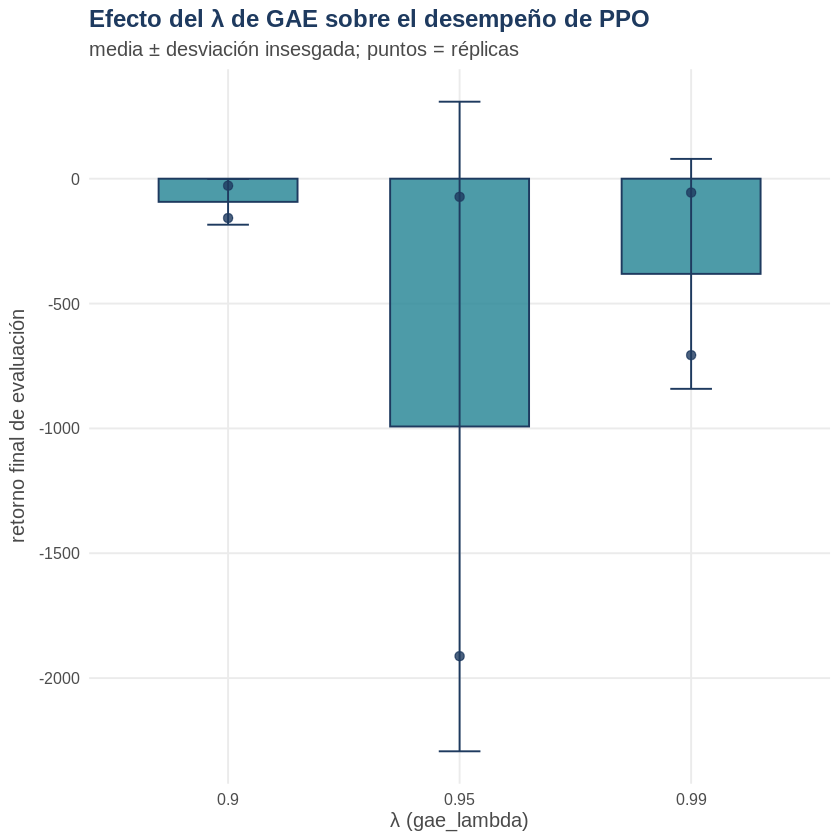

In [9]:
res_lambda <- barrido("gae_lambda", c(0.90, 0.95, 0.99), SWEEP_STEPS, SWEEP_REPLICAS, 200L)
b2 <- df_barrido(res_lambda); p2 <- df_puntos(res_lambda)

ggplot(b2, aes(factor(valor), media)) +
  geom_col(fill = TEAL, alpha = 0.85, color = NAVY, width = 0.6) +
  geom_errorbar(aes(ymin = media - desv, ymax = media + desv), width = 0.18, color = NAVY) +
  geom_point(data = p2, aes(factor(valor), final), color = NAVY, size = 2.2, alpha = 0.8) +
  labs(title = "Efecto del λ de GAE sobre el desempeño de PPO",
       subtitle = "media ± desviación insesgada; puntos = réplicas",
       x = "λ (gae_lambda)", y = "retorno final de evaluación")

## Bloque 6 — El agente experto: evaluación rigurosa y contraste

Entrenamos un agente con presupuesto mayor, lo sometemos a la evaluación rigurosa del curso —treinta episodios deterministas, con media y desviación insesgada— y lo grabamos con `SEMILLA_VIS`. Éste es el único resultado que el cuaderno establece con solidez, y lo es precisamente porque se evalúa con rigor. El contraste final, entre el módulo aleatorio que giraba sin control y el experto que se posa con suavidad, condensa todo el recorrido.


Evaluación rigurosa (30 episodios deterministas):
  retorno = 187.3 ± 72.0  (desviación insesgada)
  mínimo = 36.2 · máximo = 285.2 · resueltos (>=200): 14/30


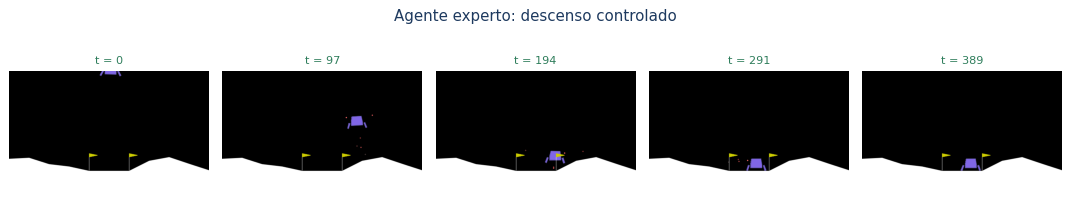

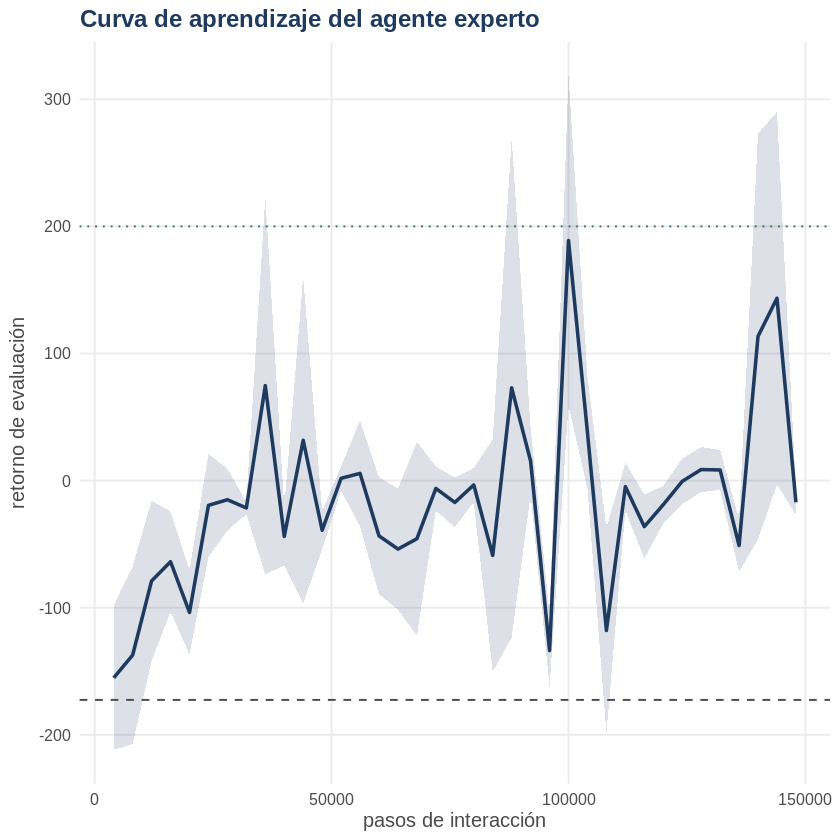

In [10]:
res_exp <- experto_completo(HERO_STEPS, EVAL_FREQ, SEMILLA_GLOBAL, SEMILLA_VIS,
                            "lunarlander_despues.gif", "montaje_despues.png", 30L)

# Curva de aprendizaje del experto
df_exp <- data.frame(pasos = as.numeric(unlist(res_exp$pasos)),
                     media = as.numeric(unlist(res_exp$media)),
                     desv  = as.numeric(unlist(res_exp$desv)))
print(
  ggplot(df_exp, aes(pasos, media)) +
    geom_ribbon(aes(ymin = media - desv, ymax = media + desv), alpha = 0.15, fill = NAVY) +
    geom_line(color = NAVY, linewidth = 1) +
    geom_hline(yintercept = 200, linetype = "dotted", color = GREEN) +
    geom_hline(yintercept = mean(ret_aleatorio), linetype = "dashed", color = GRAY) +
    labs(title = "Curva de aprendizaje del agente experto",
         x = "pasos de interacción", y = "retorno de evaluación")
)

cat(sprintf("\nEvaluación rigurosa (%d episodios deterministas):\n", res_exp$n_rig))
cat(sprintf("  retorno = %.1f ± %.1f  (desviación insesgada)\n", res_exp$eval_media, res_exp$eval_desv))
cat(sprintf("  mínimo = %.1f · máximo = %.1f · resueltos (>=200): %d/%d\n",
            res_exp$eval_min, res_exp$eval_max, res_exp$resueltos, res_exp$n_rig))
mostrar_png("montaje_despues.png")
mostrar_gif("lunarlander_despues.gif")

### 6.1. Distribución de retornos: antes y después

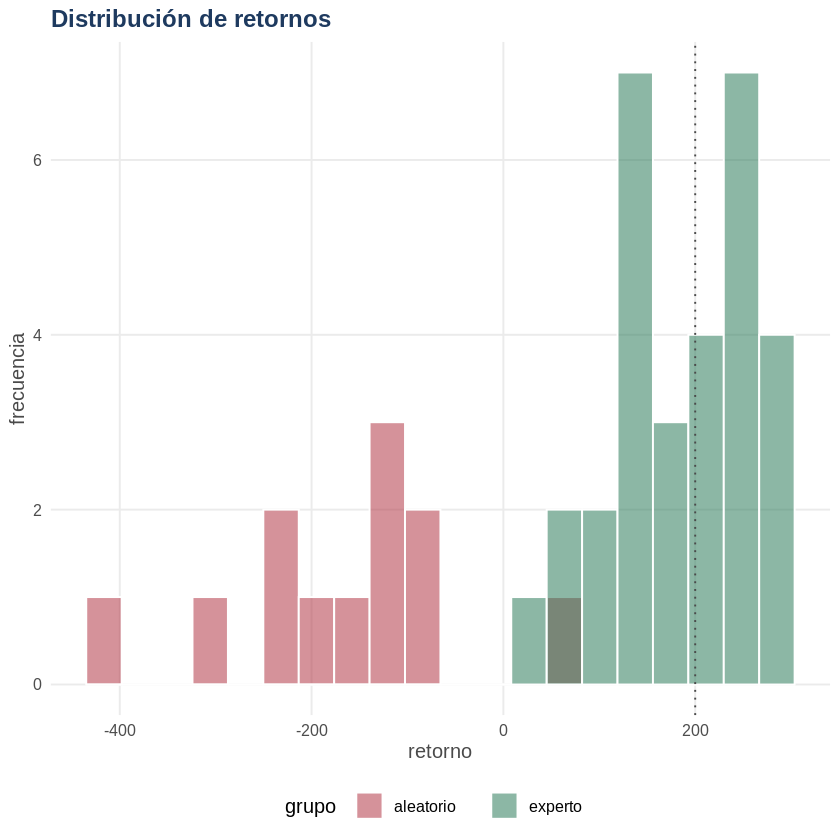

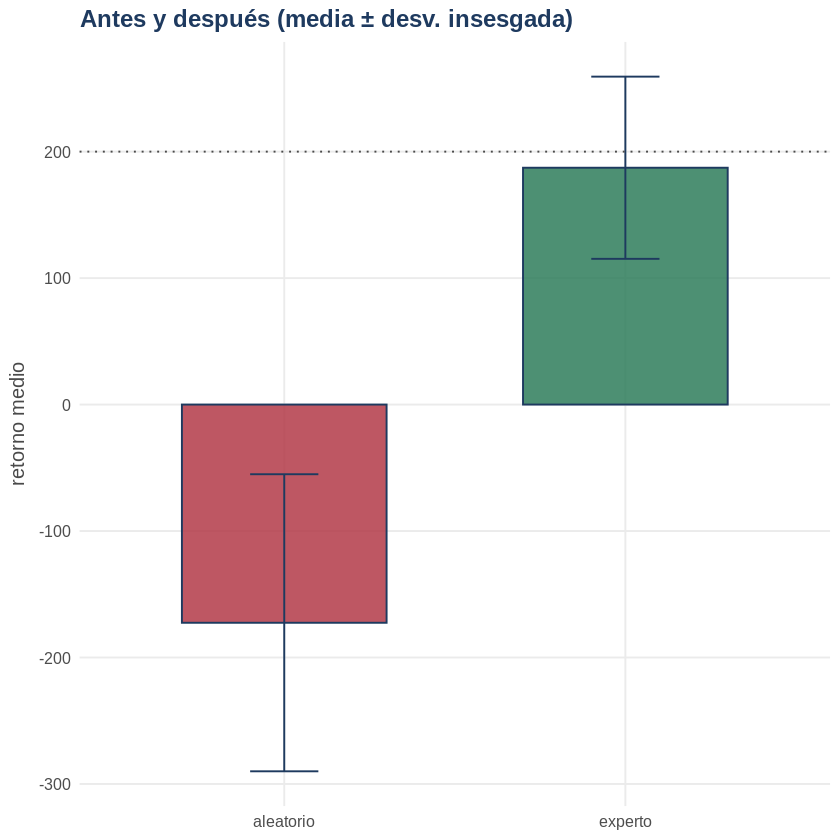

In [11]:
df_contraste <- rbind(
  data.frame(grupo = "aleatorio", retorno = ret_aleatorio),
  data.frame(grupo = "experto",  retorno = as.numeric(unlist(res_exp$eval_retornos))))

print(
  ggplot(df_contraste, aes(retorno, fill = grupo)) +
    geom_histogram(alpha = 0.55, position = "identity", bins = 20, color = "white") +
    geom_vline(xintercept = 200, linetype = "dotted", color = GRAY) +
    scale_fill_manual(values = c(aleatorio = RED, experto = GREEN)) +
    labs(title = "Distribución de retornos", x = "retorno", y = "frecuencia")
)

df_resumen <- df_contraste %>% group_by(grupo) %>%
  summarise(media = mean(retorno), desv = sd(retorno), .groups = "drop")
print(
  ggplot(df_resumen, aes(grupo, media, fill = grupo)) +
    geom_col(width = 0.6, alpha = 0.85, color = NAVY) +
    geom_errorbar(aes(ymin = media - desv, ymax = media + desv), width = 0.2, color = NAVY) +
    geom_hline(yintercept = 200, linetype = "dotted", color = GRAY) +
    scale_fill_manual(values = c(aleatorio = RED, experto = GREEN)) +
    labs(title = "Antes y después (media ± desv. insesgada)", x = NULL, y = "retorno medio") +
    theme(legend.position = "none")
)

## Bloque 7 — Síntesis

Este cuaderno reprodujo en R, orquestando sobre un núcleo de PyTorch, el estudio comparativo de la Clase 6. Cuatro hilos conviene retener.

**Primero, la reconvergencia de las dos ramas.** DQN, A2C y PPO aprenden sobre un mismo problema bajo un único marco experimental; las familias que la teoría presentó separadas se reencuentran en la práctica.

**Segundo, la acumulación de mejoras como hipótesis, no como certeza.** Double DQN y Dueling son refinamientos modulares sobre el Q-Learning, pero su ventaja teórica no emergió con nitidez bajo una sola semilla: el ruido entre corridas la sepultó. Las ideas escalan; su verificación empírica exige potencia estadística.

**Tercero, el gobierno de los hiperparámetros y los límites de su medición.** Los barridos de $\epsilon$ y de $\lambda$ recordaron los valores canónicos sin poder confirmarlos: con pocas réplicas, las bandas de error se solapan y ninguna jerarquía resiste el escrutinio.

**Cuarto, el rigor por encima del método.** El único resultado sólido —el agente experto que resuelve LunarLander sobre treinta episodios— lo es porque se evaluó como debe evaluarse. Un agente potente mal evaluado vale menos que uno modesto bien estudiado. Ese principio, y no algoritmo alguno, es el legado más duradero del curso.

> **Nota sobre la arquitectura.** Que R haya orquestado un estudio de aprendizaje por refuerzo profundo sin escribir una sola línea de PyTorch, delegando el núcleo en Python vía reticulate y reservándose el análisis y la visualización con ggplot2, ilustra una práctica de ingeniería tan pertinente como la teoría misma: emplear cada herramienta en aquello que mejor hace.

---
*Cuaderno R · Clase 6 · Universidad Austral · Dr. Darío Ezequiel Díaz · 2026*